In [15]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.3.5
pandas 3.0.0
sklearn 1.8.0
torch 2.10.0+cu130
cuda:0


# 数据预处理

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)), # 加入标准化
])
train_dataset = datasets.FashionMNIST(root='../day21/data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='../day21/data', train=False, transform=transform, download=True)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
# 获取并输出train_dataset中单个元素的shape
sample, label = train_dataset[0]
print(f"Train dataset单个元素的shape: {sample.shape}")


Train dataset size: 60000
Test dataset size: 10000
Train dataset单个元素的shape: torch.Size([1, 28, 28])


# 搭建模型

In [17]:
import torch
import torch.nn as nn

class SeparableConv(nn.Module):
    """
    深度可分离卷积实现 (depthwise + pointwise)
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        super(SeparableConv, self).__init__()
        # 深度卷积: 每个输入通道独立卷积
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size,
                                   stride=stride, padding=padding, groups=in_channels, bias=bias)
        # 逐点卷积: 1x1卷积混合通道信息
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                                   stride=1, padding=0, bias=bias)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x


class FashionMNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        # 更深的SeparableConv网络：4个block，通道数逐层递增
        self.features = nn.Sequential(
            # block1：1→16
            SeparableConv(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            SeparableConv(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 14×14

            # block2：16→32
            SeparableConv(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            SeparableConv(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 7×7

            # block3：32→64
            SeparableConv(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            SeparableConv(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # block4：64→128
            SeparableConv(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            SeparableConv(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)) # 全局平均池化，输出1×1
        )

        # 分类头
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
model = FashionMNISTModel()

In [18]:
dummy_input = torch.randn(1,1,28,28)
output = model(dummy_input)
print(f"Output shape: {output.shape}")

Output shape: torch.Size([1, 10])


In [19]:
# 计算并打印模型总参数量
total_params = sum(p.numel() for p in model.parameters())
print(f"模型总参数量: {total_params:,}")


模型总参数量: 38,788


# 训练

In [20]:
import torch.optim as optim
import wangdao_train

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
trainer = wangdao_train.Trainer(model, train_loader, test_loader, criterion, optimizer, device,eval_step=500)

num_epochs = 10 
trainer.train(num_epochs)


[Step 500] Val Loss: 0.5076 Val Acc: 0.8175
[Step 1000] Val Loss: 0.5016 Val Acc: 0.8160
[Step 1500] Val Loss: 0.4031 Val Acc: 0.8468
Epoch [1/10]  Train Loss: 0.5237  Train Acc: 0.8110
[Step 2000] Val Loss: 0.3906 Val Acc: 0.8589
[Step 2500] Val Loss: 0.3946 Val Acc: 0.8539
[Step 3000] Val Loss: 0.3422 Val Acc: 0.8777
[Step 3500] Val Loss: 0.3375 Val Acc: 0.8783
Epoch [2/10]  Train Loss: 0.3581  Train Acc: 0.8673
[Step 4000] Val Loss: 0.3439 Val Acc: 0.8740
[Step 4500] Val Loss: 0.3979 Val Acc: 0.8559
[Step 5000] Val Loss: 0.3459 Val Acc: 0.8767
[Step 5500] Val Loss: 0.3187 Val Acc: 0.8856
Epoch [3/10]  Train Loss: 0.3265  Train Acc: 0.8794
[Step 6000] Val Loss: 0.3232 Val Acc: 0.8812
[Step 6500] Val Loss: 0.3459 Val Acc: 0.8713
[Step 7000] Val Loss: 0.3333 Val Acc: 0.8775
[Step 7500] Val Loss: 0.3444 Val Acc: 0.8782
Epoch [4/10]  Train Loss: 0.3012  Train Acc: 0.8890
[Step 8000] Val Loss: 0.2993 Val Acc: 0.8895
[Step 8500] Val Loss: 0.3034 Val Acc: 0.8903
[Step 9000] Val Loss: 0.3227

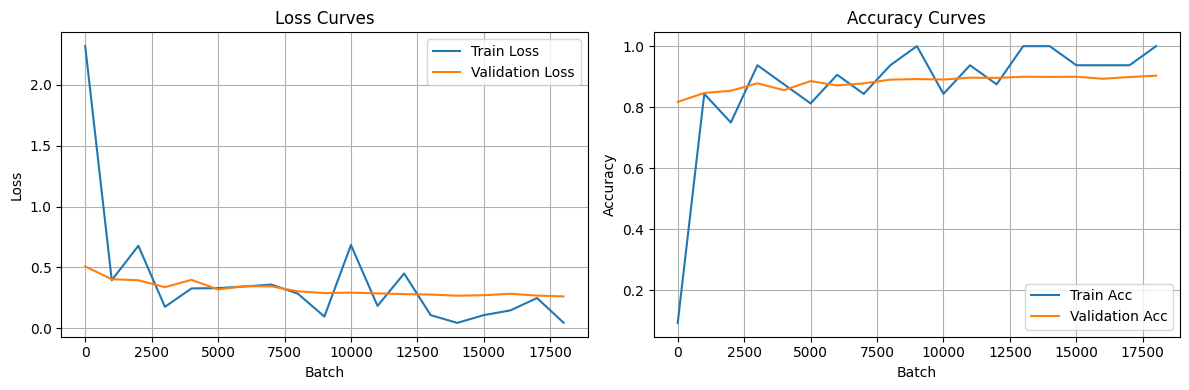

In [21]:
trainer.plot_curves()
